#  Data Check and EDA

This notebook loads the three raw CSV files for the **Personalized Content Recommendation Engine**, checks data quality, and performs exploratory data analysis (EDA) to understand users, content, and interactions before model building.

## Objectives
- Load and inspect the raw datasets
- Check shapes, dtypes, missing values, and duplicates
- Validate key relationships across files
- Explore user, content, and interaction distributions
- Merge the datasets for richer behavioral analysis
- Save selected figures for the project report


## 1. Imports and setup

In [9]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11
plt.rcParams["xtick.labelsize"] = 10
plt.rcParams["ytick.labelsize"] = 10

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 120)
from pathlib import Path
import os

NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR
RAW_DIR = PROJECT_ROOT / "data" / "raw"
FIG_DIR = PROJECT_ROOT / "results" / "figures"
METRICS_DIR = PROJECT_ROOT / "results" / "metrics"

FIG_DIR.mkdir(parents=True, exist_ok=True)
METRICS_DIR.mkdir(parents=True, exist_ok=True)

print("Notebook dir:", NOTEBOOK_DIR)
print("Project root:", PROJECT_ROOT)
print("Raw data path:", RAW_DIR)
print("Users exists:", (RAW_DIR / "users.csv").exists())
print("Content exists:", (RAW_DIR / "content.csv").exists())
print("Interactions exists:", (RAW_DIR / "interactions.csv").exists())

Notebook dir: C:\Users\Owen\Documents\Hertsfordshire\Projects\personalized-content
Project root: C:\Users\Owen\Documents\Hertsfordshire\Projects\personalized-content
Raw data path: C:\Users\Owen\Documents\Hertsfordshire\Projects\personalized-content\data\raw
Users exists: True
Content exists: True
Interactions exists: True


## 2. Load the raw datasets

In [10]:
users = pd.read_csv(RAW_DIR / "users.csv")
content = pd.read_csv(RAW_DIR / "content.csv")
interactions = pd.read_csv(RAW_DIR / "interactions.csv")

print("Users shape:", users.shape)
print("Content shape:", content.shape)
print("Interactions shape:", interactions.shape)


Users shape: (450, 19)
Content shape: (900, 18)
Interactions shape: (22000, 15)


## 3. Preview the datasets

In [11]:
display(users.head())
display(content.head())
display(interactions.head())

,user_id,age_group,study_level,study_mode,persona,favorite_categories,preferred_formats,preferred_moods,session_pattern,activity_level,time_availability,budget_sensitivity,campus_affinity,preferred_days,device_preference,home_region,discovery_style,avg_session_minutes,onboarding_interest_score
0,U0001,21-23,Postgraduate Taught,Full-time,Pop Culture Browser,Events|Music,Video|Playlist,Relaxed|Curious,Morning,High,Tight Schedule,Low,Mixed,Mixed,Laptop,Watford,Trendy,36,0.70
1,U0002,24-26,Undergraduate,Full-time,Career Builder,Tech|Finance|Career,Long Video|Article,Focused|Curious,Afternoon,Medium,Balanced,Low,Mixed,Mixed,Mobile,Remote/Online,Balanced,38,0.93
2,U0003,18-20,Undergraduate,Full-time,Career Builder,Finance|Tech|Study|Career,Guide|Podcast,Focused|Curious,Morning,Medium,Balanced,Low,Campus-Centered,Weekend,Mobile,Hatfield,Balanced,28,0.69
3,U0004,21-23,Undergraduate,Full-time,Minimalist Achiever,Productivity|Career|Study|Wellness,Short Video|Guide,Focused|Calm,Afternoon,High,Flexible,High,Mixed,Weekend,Mobile,Remote/Online,Familiar,48,0.83
4,U0005,21-23,Postgraduate Taught,Full-time,Wellness Seeker,Food|Fitness|Study|Lifestyle,Short Video|Article|Guide,Motivated|Relaxed,Morning,High,Balanced,Medium,Off-Campus,Weekday,Mobile,Watford,Familiar,25,0.80


,content_id,title,category,subcategory,tags,format,mood,depth_level,duration_minutes,cost_band,time_of_day_fit,location_scope,is_local_content,freshness_band,publish_date,popularity_score,recency_score,content_quality_score
0,C0001,Stretching Routines for Long Study Days for Better Energy,Fitness,Beginner Fitness,beginner|workout|gym|stretching,Video,Focused,Light,35,Low,Afternoon,Online,0,New,2025-09-28,71,19,73
1,C0002,A Simple Gym Plan for Absolute Beginners for Beginners,Fitness,Beginner Fitness,fitness|beginner|stretching|workout,Guide,Focused,Moderate,12,Low,Weekend,Online,0,Evergreen,2025-10-22,65,31,92
2,C0003,Short Entertainment Picks for Study Breaks This Weekend,Entertainment,Movies,shows|entertainment|anime|gaming,Carousel,Excited,Light,7,High,Afternoon,Online,0,New,2025-09-06,68,8,78
3,C0004,How to Recover After an Overloaded Week Without a Huge Routine,Wellness,Mindfulness,stress|wellness|mental health|balance,Podcast,Motivated,Moderate,31,Free,Late Night,Online,0,Recent,2026-01-09,40,70,86
4,C0005,Sleep Routines That Feel Realistic for Students for Students,Wellness,Stress Relief,sleep|mental health|stress|mindfulness,Podcast,Calm,Light,16,High,Weekend,Online,0,Evergreen,2026-01-07,76,69,98


,interaction_id,user_id,content_id,viewed,liked,saved,shared,completed,dwell_time_percent,rating,engaged_minutes,interaction_timestamp,engagement_score,interaction_day_type,recommendation_surface
0,I000001,U0133,C0103,1,0,0,0,0,72,NaN,23.0,2026-02-06 22:41:00,2.44,Weekday,Home Feed
1,I000002,U0085,C0300,1,0,0,1,1,90,NaN,3.6,2025-09-06 08:06:00,8.30,Weekend,Trending
2,I000003,U0001,C0370,1,1,1,1,0,96,NaN,1.9,2025-09-19 09:56:00,10.42,Weekday,For You
3,I000004,U0410,C0368,1,0,0,0,0,56,3.0,1.1,2025-12-23 07:27:00,4.52,Weekday,For You
4,I000005,U0312,C0668,0,0,0,0,0,65,NaN,5.2,2025-10-02 08:00:00,1.30,Weekday,Because You Liked


## 4. Basic structure check

In [12]:
print("Users columns:")
print(users.columns.tolist())

print("\nContent columns:")
print(content.columns.tolist())

print("\nInteractions columns:")
print(interactions.columns.tolist())


Users columns:
['user_id', 'age_group', 'study_level', 'study_mode', 'persona', 'favorite_categories', 'preferred_formats', 'preferred_moods', 'session_pattern', 'activity_level', 'time_availability', 'budget_sensitivity', 'campus_affinity', 'preferred_days', 'device_preference', 'home_region', 'discovery_style', 'avg_session_minutes', 'onboarding_interest_score']

Content columns:
['content_id', 'title', 'category', 'subcategory', 'tags', 'format', 'mood', 'depth_level', 'duration_minutes', 'cost_band', 'time_of_day_fit', 'location_scope', 'is_local_content', 'freshness_band', 'publish_date', 'popularity_score', 'recency_score', 'content_quality_score']

Interactions columns:
['interaction_id', 'user_id', 'content_id', 'viewed', 'liked', 'saved', 'shared', 'completed', 'dwell_time_percent', 'rating', 'engaged_minutes', 'interaction_timestamp', 'engagement_score', 'interaction_day_type', 'recommendation_surface']


In [13]:
print("Users dtypes:")
display(users.dtypes.to_frame("dtype"))

print("Content dtypes:")
display(content.dtypes.to_frame("dtype"))

print("Interactions dtypes:")
display(interactions.dtypes.to_frame("dtype"))


Users dtypes:


,dtype
user_id,object
age_group,object
study_level,object
study_mode,object
persona,object
favorite_categories,object
preferred_formats,object
preferred_moods,object
session_pattern,object
activity_level,object


Content dtypes:


,dtype
content_id,object
title,object
category,object
subcategory,object
tags,object
format,object
mood,object
depth_level,object
duration_minutes,int64
cost_band,object


Interactions dtypes:


,dtype
interaction_id,object
user_id,object
content_id,object
viewed,int64
liked,int64
saved,int64
shared,int64
completed,int64
dwell_time_percent,int64
rating,float64


## 5. Standard cleaning and type fixes

At this stage, the goal is not heavy transformation. We only fix obvious formatting issues needed for good analysis.


In [14]:
# Standardise column names
users.columns = users.columns.str.strip().str.lower()
content.columns = content.columns.str.strip().str.lower()
interactions.columns = interactions.columns.str.strip().str.lower()

# Parse dates
content["publish_date"] = pd.to_datetime(content["publish_date"], errors="coerce")
interactions["interaction_timestamp"] = pd.to_datetime(
    interactions["interaction_timestamp"], errors="coerce"
)

# Convert numeric columns where appropriate
numeric_cols_content = [
    "duration_minutes", "is_local_content", "popularity_score",
    "recency_score", "content_quality_score"
]
numeric_cols_interactions = [
    "viewed", "liked", "saved", "shared", "completed",
    "dwell_time_percent", "rating", "engaged_minutes", "engagement_score"
]

for col in numeric_cols_content:
    content[col] = pd.to_numeric(content[col], errors="coerce")

for col in numeric_cols_interactions:
    interactions[col] = pd.to_numeric(interactions[col], errors="coerce")

print("Cleaning and type fixes applied.")


Cleaning and type fixes applied.


## 6. Data quality checks

In [15]:
def quality_summary(df, name):
    summary = pd.DataFrame({
        "column": df.columns,
        "dtype": df.dtypes.astype(str).values,
        "missing_count": df.isna().sum().values,
        "missing_pct": (df.isna().mean() * 100).round(2).values,
        "n_unique": df.nunique(dropna=False).values
    })
    print(f"{name} — shape: {df.shape}")
    return summary.sort_values(["missing_pct", "n_unique"], ascending=[False, True])

display(quality_summary(users, "Users"))
display(quality_summary(content, "Content"))
display(quality_summary(interactions, "Interactions"))


Users — shape: (450, 19)


,column,dtype,missing_count,missing_pct,n_unique
3,study_mode,object,0,0.0,2
2,study_level,object,0,0.0,3
9,activity_level,object,0,0.0,3
10,time_availability,object,0,0.0,3
11,budget_sensitivity,object,0,0.0,3
12,campus_affinity,object,0,0.0,3
13,preferred_days,object,0,0.0,3
14,device_preference,object,0,0.0,3
1,age_group,object,0,0.0,4
16,discovery_style,object,0,0.0,4


Content — shape: (900, 18)


,column,dtype,missing_count,missing_pct,n_unique
12,is_local_content,int64,0,0.0,2
7,depth_level,object,0,0.0,3
13,freshness_band,object,0,0.0,3
9,cost_band,object,0,0.0,4
10,time_of_day_fit,object,0,0.0,5
11,location_scope,object,0,0.0,7
6,mood,object,0,0.0,8
5,format,object,0,0.0,9
2,category,object,0,0.0,14
8,duration_minutes,int64,0,0.0,44


Interactions — shape: (22000, 15)


,column,dtype,missing_count,missing_pct,n_unique
9,rating,float64,14438,65.63,6
3,viewed,int64,0,0.00,2
4,liked,int64,0,0.00,2
5,saved,int64,0,0.00,2
6,shared,int64,0,0.00,2
7,completed,int64,0,0.00,2
13,interaction_day_type,object,0,0.00,2
14,recommendation_surface,object,0,0.00,6
8,dwell_time_percent,int64,0,0.00,96
10,engaged_minutes,float64,0,0.00,365


In [16]:
print("Duplicate rows")
print("Users:", users.duplicated().sum())
print("Content:", content.duplicated().sum())
print("Interactions:", interactions.duplicated().sum())

print("\nDuplicate IDs")
print("Duplicate user_id:", users["user_id"].duplicated().sum())
print("Duplicate content_id:", content["content_id"].duplicated().sum())
print("Duplicate interaction_id:", interactions["interaction_id"].duplicated().sum())


Duplicate rows
Users: 0
Content: 0
Interactions: 0

Duplicate IDs
Duplicate user_id: 0
Duplicate content_id: 0
Duplicate interaction_id: 0


## 7. Key relationship checks

In [17]:
missing_user_refs = interactions.loc[~interactions["user_id"].isin(users["user_id"])]
missing_content_refs = interactions.loc[~interactions["content_id"].isin(content["content_id"])]

print("Interaction rows with missing user references:", len(missing_user_refs))
print("Interaction rows with missing content references:", len(missing_content_refs))


Interaction rows with missing user references: 0
Interaction rows with missing content references: 0


In [18]:
user_content_repeat = (
    interactions.groupby(["user_id", "content_id"])
    .size()
    .reset_index(name="interaction_count")
)

print("Repeated user-content pairs:", (user_content_repeat["interaction_count"] > 1).sum())
display(user_content_repeat.sort_values("interaction_count", ascending=False).head(10))


Repeated user-content pairs: 1075


,user_id,content_id,interaction_count
6907,U0150,C0457,4
10236,U0220,C0713,3
8779,U0189,C0880,3
1029,U0023,C0107,3
9193,U0198,C0396,3
2559,U0055,C0231,3
377,U0009,C0472,3
3495,U0076,C0044,3
8844,U0191,C0120,3
8881,U0191,C0773,3


## 8. Quick summaries

In [19]:
summary_table = pd.DataFrame({
    "dataset": ["users", "content", "interactions"],
    "rows": [len(users), len(content), len(interactions)],
    "columns": [users.shape[1], content.shape[1], interactions.shape[1]],
    "missing_cells": [users.isna().sum().sum(), content.isna().sum().sum(), interactions.isna().sum().sum()]
})
display(summary_table)


,dataset,rows,columns,missing_cells
0,users,450,19,0
1,content,900,18,0
2,interactions,22000,15,14438


## 9. User-level EDA

In [20]:
display(users.describe(include="all").T)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
user_id,450,450,U0450,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age_group,450,4,21-23,215,NaN,NaN,NaN,NaN,NaN,NaN,NaN
study_level,450,3,Undergraduate,242,NaN,NaN,NaN,NaN,NaN,NaN,NaN
study_mode,450,2,Full-time,349,NaN,NaN,NaN,NaN,NaN,NaN,NaN
persona,450,8,Focused Planner,70,NaN,NaN,NaN,NaN,NaN,NaN,NaN
favorite_categories,450,331,Lifestyle|Food,9,NaN,NaN,NaN,NaN,NaN,NaN,NaN
preferred_formats,450,141,Article|Guide,15,NaN,NaN,NaN,NaN,NaN,NaN,NaN
preferred_moods,450,30,Motivated|Calm,31,NaN,NaN,NaN,NaN,NaN,NaN,NaN
session_pattern,450,5,Evening,130,NaN,NaN,NaN,NaN,NaN,NaN,NaN
activity_level,450,3,Medium,210,NaN,NaN,NaN,NaN,NaN,NaN,NaN


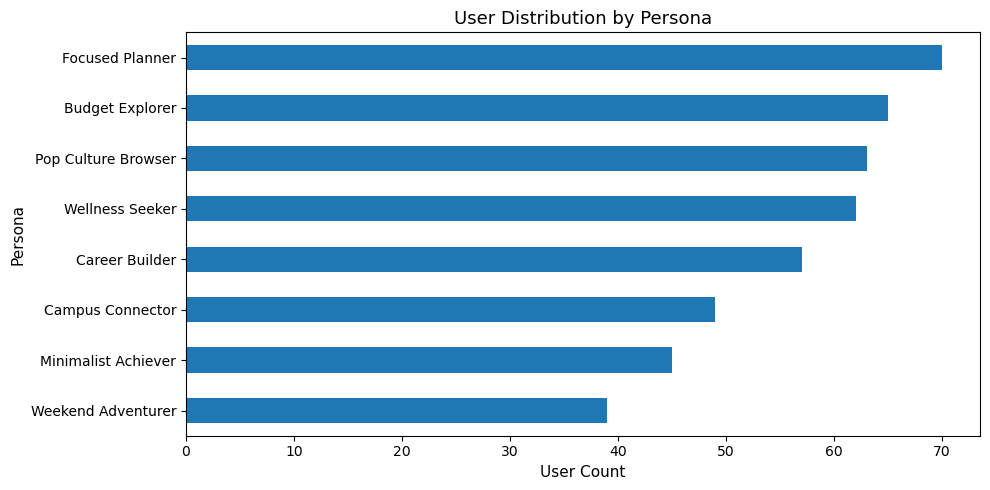

In [21]:
persona_counts = users["persona"].value_counts().sort_values(ascending=True)
persona_counts.plot(kind="barh")
plt.title("User Distribution by Persona")
plt.xlabel("User Count")
plt.ylabel("Persona")
plt.tight_layout()
plt.savefig(FIG_DIR / "user_persona_distribution.png", dpi=200, bbox_inches="tight")
plt.show()


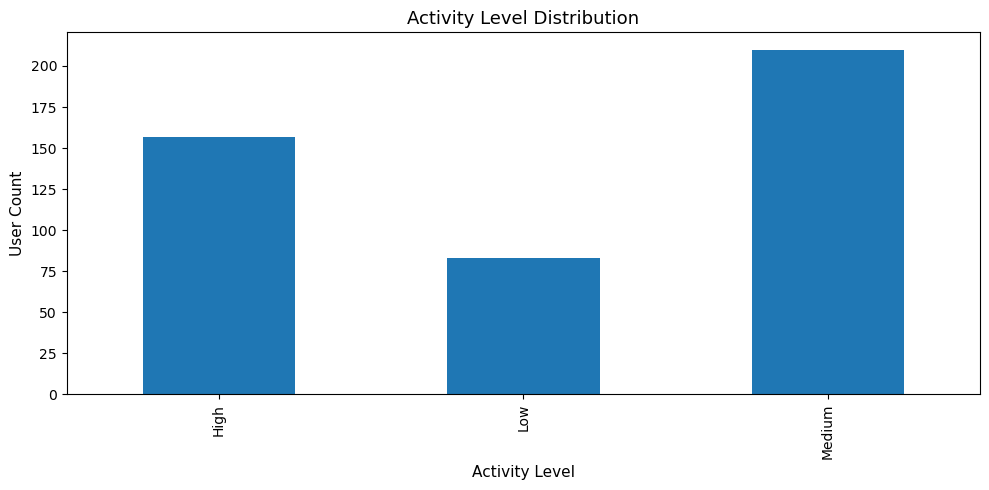

In [22]:
activity_counts = users["activity_level"].value_counts().sort_index()
activity_counts.plot(kind="bar")
plt.title("Activity Level Distribution")
plt.xlabel("Activity Level")
plt.ylabel("User Count")
plt.tight_layout()
plt.savefig(FIG_DIR / "user_activity_distribution.png", dpi=200, bbox_inches="tight")
plt.show()


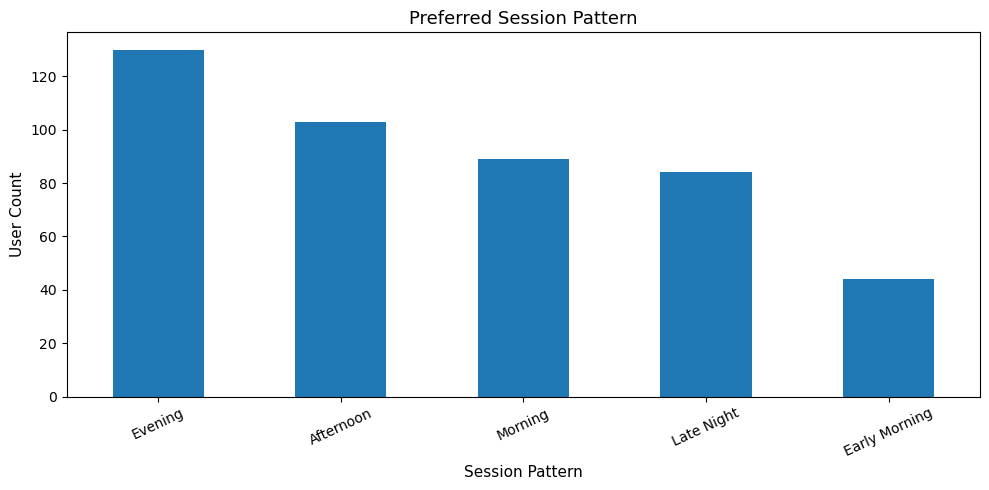

In [23]:
session_counts = users["session_pattern"].value_counts().sort_values(ascending=False)
session_counts.plot(kind="bar")
plt.title("Preferred Session Pattern")
plt.xlabel("Session Pattern")
plt.ylabel("User Count")
plt.xticks(rotation=25)
plt.tight_layout()
plt.savefig(FIG_DIR / "user_session_pattern.png", dpi=200, bbox_inches="tight")
plt.show()


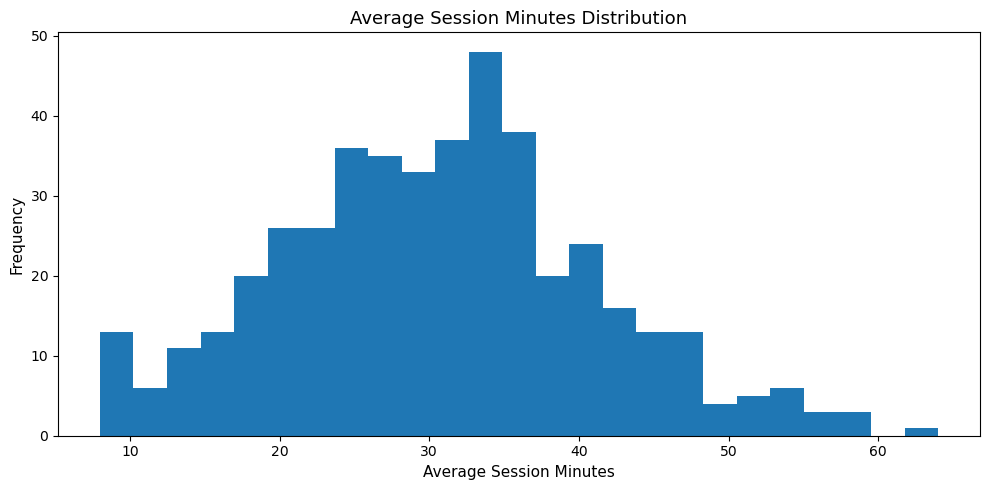

In [24]:
users["avg_session_minutes"].plot(kind="hist", bins=25)
plt.title("Average Session Minutes Distribution")
plt.xlabel("Average Session Minutes")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig(FIG_DIR / "avg_session_minutes_distribution.png", dpi=200, bbox_inches="tight")
plt.show()


### Expand pipe-separated user preferences for easier analysis

In [25]:
def explode_pipe_column(df, id_col, col_name):
    tmp = df[[id_col, col_name]].copy()
    tmp[col_name] = tmp[col_name].fillna("").str.split("|")
    tmp = tmp.explode(col_name)
    tmp[col_name] = tmp[col_name].str.strip()
    tmp = tmp[tmp[col_name] != ""]
    return tmp

user_categories = explode_pipe_column(users, "user_id", "favorite_categories")
user_formats = explode_pipe_column(users, "user_id", "preferred_formats")
user_moods = explode_pipe_column(users, "user_id", "preferred_moods")

display(user_categories.head())
display(user_formats.head())
display(user_moods.head())


,user_id,favorite_categories
0,U0001,Events
0,U0001,Music
1,U0002,Tech
1,U0002,Finance
1,U0002,Career


,user_id,preferred_formats
0,U0001,Video
0,U0001,Playlist
1,U0002,Long Video
1,U0002,Article
2,U0003,Guide


,user_id,preferred_moods
0,U0001,Relaxed
0,U0001,Curious
1,U0002,Focused
1,U0002,Curious
2,U0003,Focused


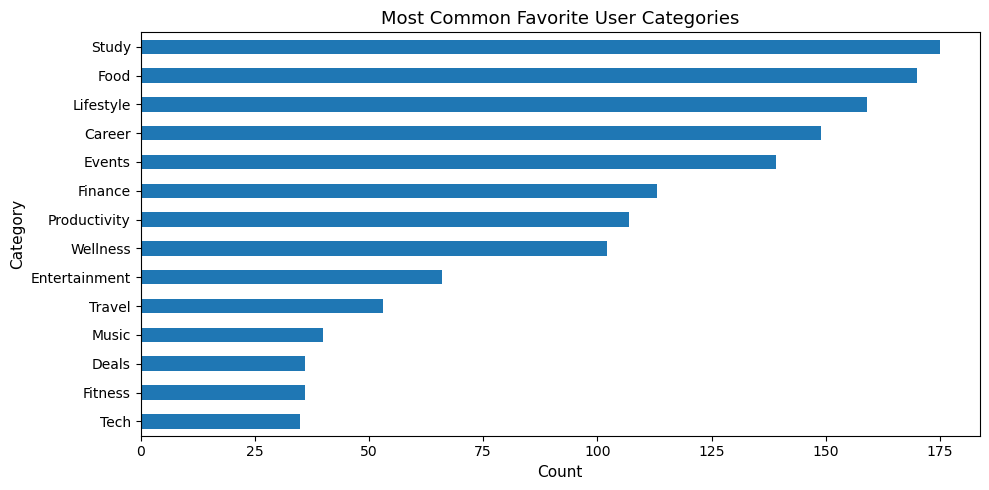

In [26]:
top_user_categories = user_categories["favorite_categories"].value_counts().sort_values(ascending=True)
top_user_categories.plot(kind="barh")
plt.title("Most Common Favorite User Categories")
plt.xlabel("Count")
plt.ylabel("Category")
plt.tight_layout()
plt.savefig(FIG_DIR / "user_favorite_categories.png", dpi=200, bbox_inches="tight")
plt.show()


## 10. Content-level EDA

In [27]:
display(content.describe(include="all").T)

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
content_id,900,900,C0900,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
title,900,322,Flashcard Systems Students Actually Keep Using on a Tight Timetable,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN
category,900,14,Food,84,NaN,NaN,NaN,NaN,NaN,NaN,NaN
subcategory,900,69,Room Setup,23,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tags,900,854,entertainment|weekend watch|movies|shows,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
format,900,9,Article,198,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mood,900,8,Curious,195,NaN,NaN,NaN,NaN,NaN,NaN,NaN
depth_level,900,3,Light,387,NaN,NaN,NaN,NaN,NaN,NaN,NaN
duration_minutes,900.0,NaN,NaN,NaN,13.016667,1.0,5.0,9.0,20.0,44.0,10.602052
cost_band,900,4,Low,313,NaN,NaN,NaN,NaN,NaN,NaN,NaN


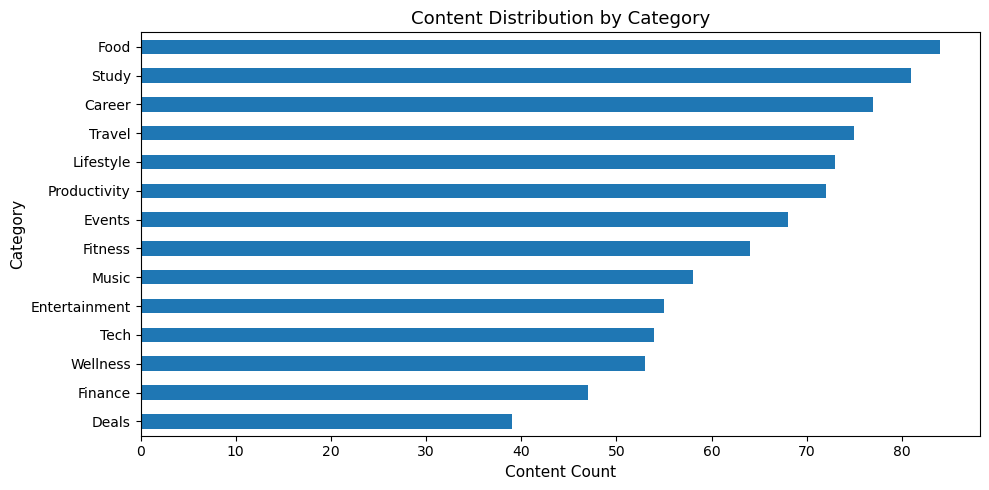

In [28]:
content["category"].value_counts().sort_values(ascending=True).plot(kind="barh")
plt.title("Content Distribution by Category")
plt.xlabel("Content Count")
plt.ylabel("Category")
plt.tight_layout()
plt.savefig(FIG_DIR / "content_category_distribution.png", dpi=200, bbox_inches="tight")
plt.show()


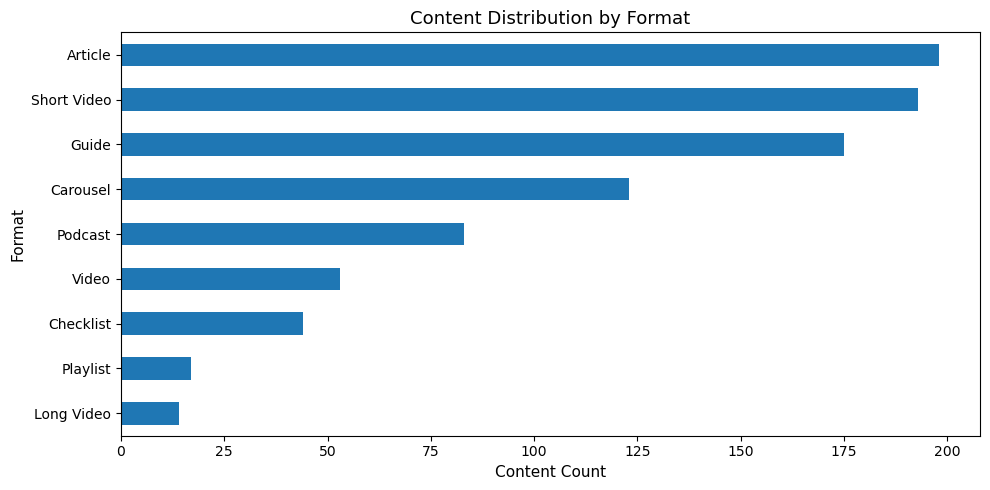

In [29]:
content["format"].value_counts().sort_values(ascending=True).plot(kind="barh")
plt.title("Content Distribution by Format")
plt.xlabel("Content Count")
plt.ylabel("Format")
plt.tight_layout()
plt.savefig(FIG_DIR / "content_format_distribution.png", dpi=200, bbox_inches="tight")
plt.show()


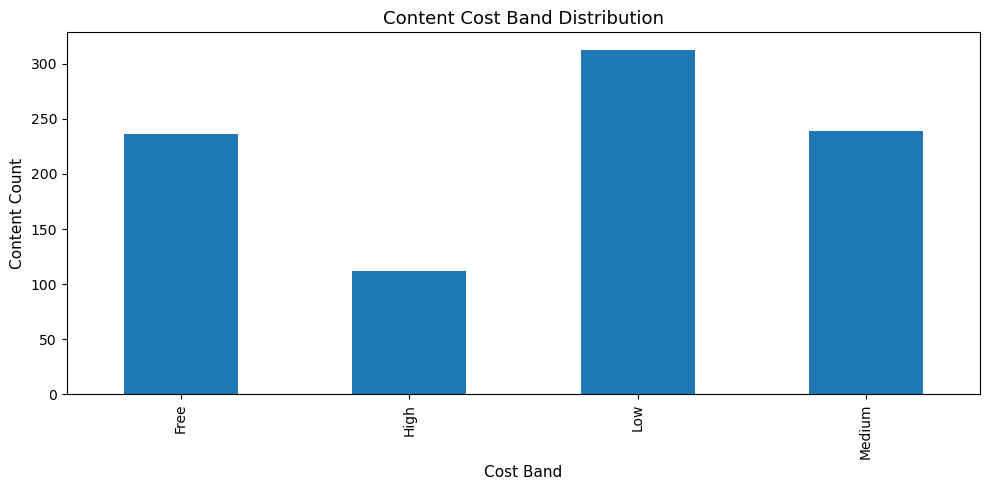

In [30]:
content["cost_band"].value_counts().sort_index().plot(kind="bar")
plt.title("Content Cost Band Distribution")
plt.xlabel("Cost Band")
plt.ylabel("Content Count")
plt.tight_layout()
plt.savefig(FIG_DIR / "content_cost_band_distribution.png", dpi=200, bbox_inches="tight")
plt.show()


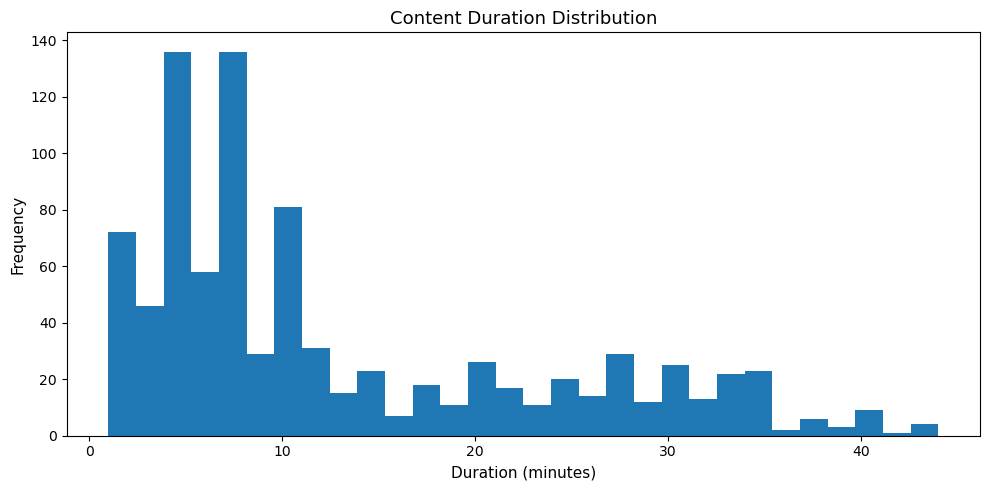

In [31]:
content["duration_minutes"].plot(kind="hist", bins=30)
plt.title("Content Duration Distribution")
plt.xlabel("Duration (minutes)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig(FIG_DIR / "content_duration_distribution.png", dpi=200, bbox_inches="tight")
plt.show()


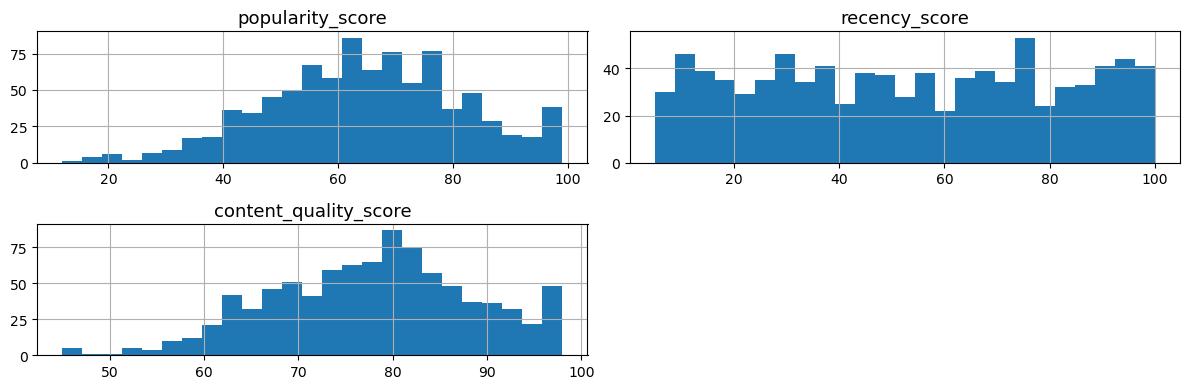

In [32]:
content[["popularity_score", "recency_score", "content_quality_score"]].hist(bins=25, figsize=(12, 4))
plt.tight_layout()
plt.savefig(FIG_DIR / "content_score_distributions.png", dpi=200, bbox_inches="tight")
plt.show()


### Expand content tags

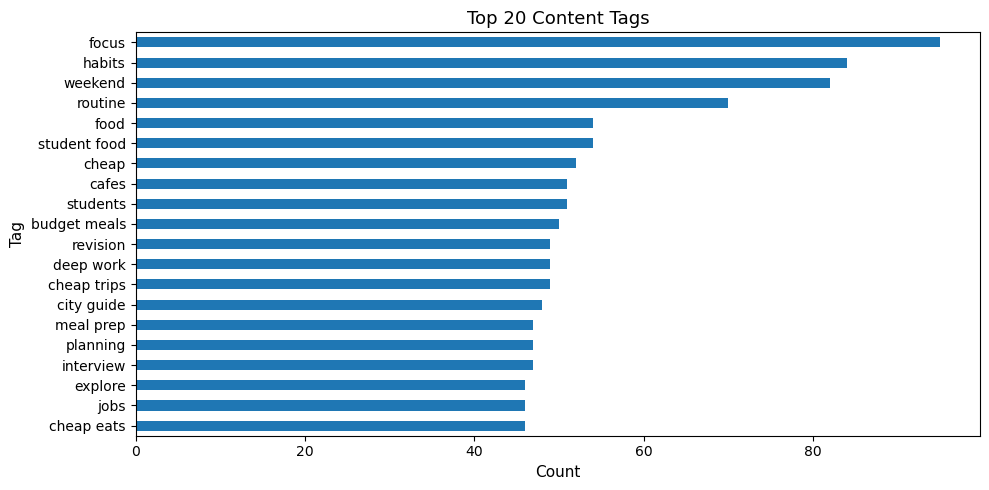

In [33]:
content_tags = explode_pipe_column(content, "content_id", "tags")
top_tags = content_tags["tags"].value_counts().head(20).sort_values(ascending=True)

top_tags.plot(kind="barh")
plt.title("Top 20 Content Tags")
plt.xlabel("Count")
plt.ylabel("Tag")
plt.tight_layout()
plt.savefig(FIG_DIR / "top_content_tags.png", dpi=200, bbox_inches="tight")
plt.show()


## 11. Interaction-level EDA

In [34]:
display(interactions.describe(include="all").T)

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
interaction_id,22000,22000,I022000,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
user_id,22000,450,U0305,76,NaN,NaN,NaN,NaN,NaN,NaN,NaN
content_id,22000,900,C0309,52,NaN,NaN,NaN,NaN,NaN,NaN,NaN
viewed,22000.0,NaN,NaN,NaN,0.897682,0.0,1.0,1.0,1.0,1.0,0.303073
liked,22000.0,NaN,NaN,NaN,0.455364,0.0,0.0,0.0,1.0,1.0,0.498015
saved,22000.0,NaN,NaN,NaN,0.327318,0.0,0.0,0.0,1.0,1.0,0.469245
shared,22000.0,NaN,NaN,NaN,0.170136,0.0,0.0,0.0,0.0,1.0,0.375761
completed,22000.0,NaN,NaN,NaN,0.4345,0.0,0.0,0.0,1.0,1.0,0.495702
dwell_time_percent,22000.0,NaN,NaN,NaN,60.871455,5.0,44.0,61.0,78.0,100.0,23.094387
rating,7562.0,NaN,NaN,NaN,3.906903,1.0,3.0,4.0,5.0,5.0,0.871028


In [35]:
interaction_binary_cols = ["viewed", "liked", "saved", "shared", "completed"]
interaction_rates = interactions[interaction_binary_cols].mean().sort_values(ascending=False) * 100
display(interaction_rates.round(2).to_frame("rate_pct"))


,rate_pct
viewed,89.77
liked,45.54
completed,43.45
saved,32.73
shared,17.01


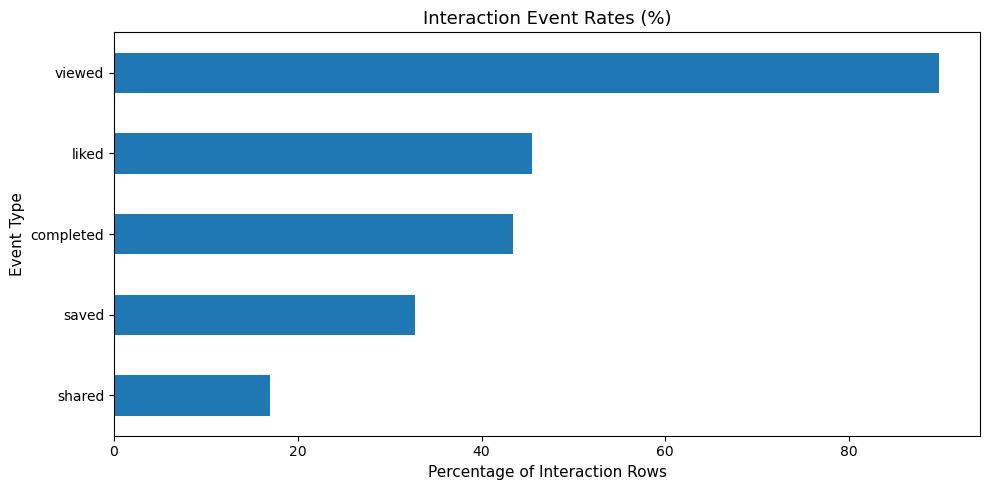

In [36]:
interaction_rates.sort_values().plot(kind="barh")
plt.title("Interaction Event Rates (%)")
plt.xlabel("Percentage of Interaction Rows")
plt.ylabel("Event Type")
plt.tight_layout()
plt.savefig(FIG_DIR / "interaction_event_rates.png", dpi=200, bbox_inches="tight")
plt.show()


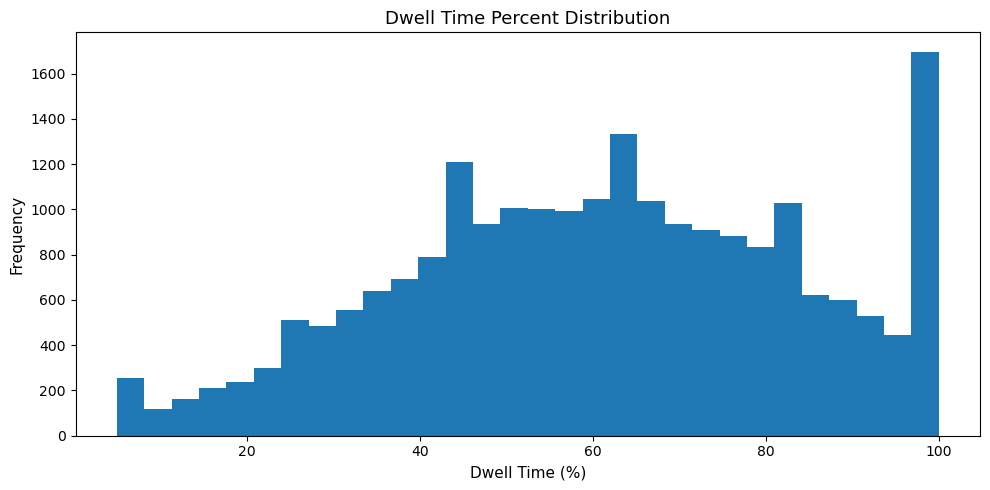

In [37]:
interactions["dwell_time_percent"].plot(kind="hist", bins=30)
plt.title("Dwell Time Percent Distribution")
plt.xlabel("Dwell Time (%)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig(FIG_DIR / "dwell_time_distribution.png", dpi=200, bbox_inches="tight")
plt.show()


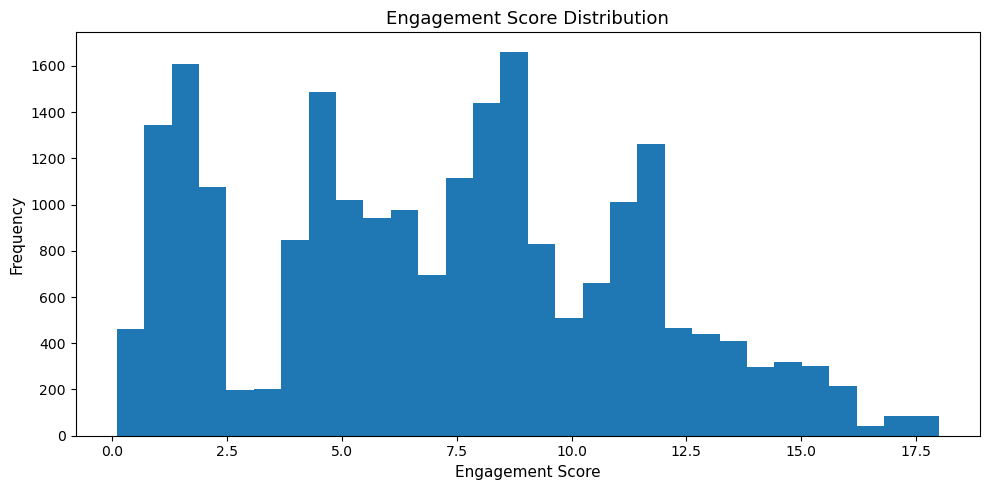

In [38]:
interactions["engagement_score"].plot(kind="hist", bins=30)
plt.title("Engagement Score Distribution")
plt.xlabel("Engagement Score")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig(FIG_DIR / "engagement_score_distribution.png", dpi=200, bbox_inches="tight")
plt.show()


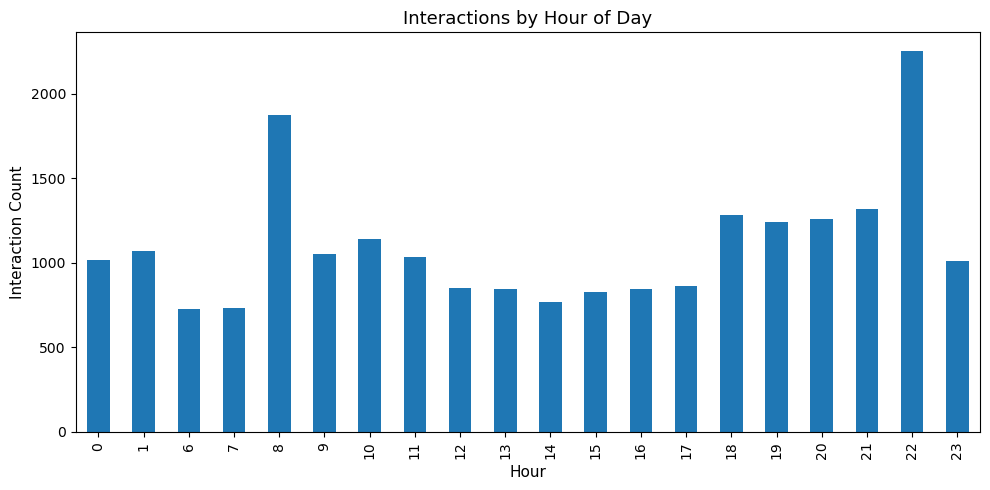

In [39]:
interactions["interaction_hour"] = interactions["interaction_timestamp"].dt.hour
hourly_counts = interactions["interaction_hour"].value_counts().sort_index()

hourly_counts.plot(kind="bar")
plt.title("Interactions by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Interaction Count")
plt.tight_layout()
plt.savefig(FIG_DIR / "interactions_by_hour.png", dpi=200, bbox_inches="tight")
plt.show()


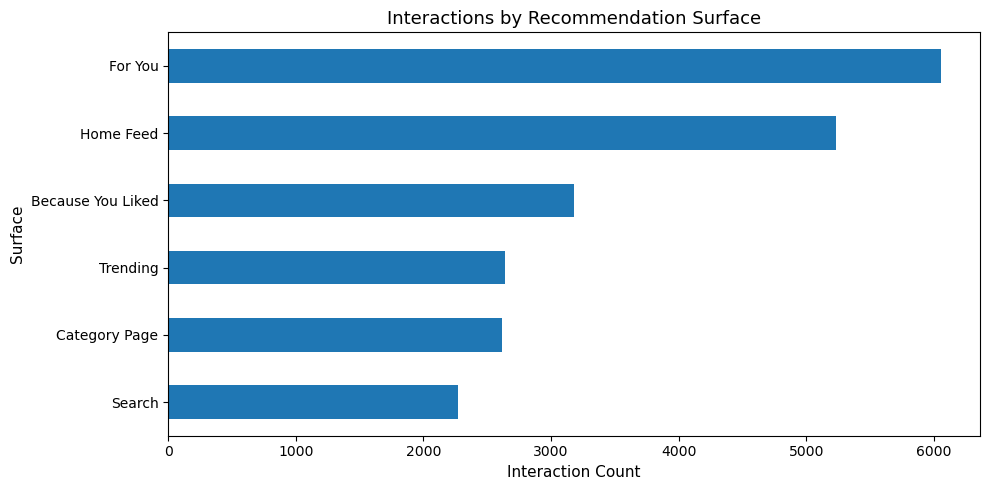

In [40]:
surface_counts = interactions["recommendation_surface"].value_counts().sort_values(ascending=True)
surface_counts.plot(kind="barh")
plt.title("Interactions by Recommendation Surface")
plt.xlabel("Interaction Count")
plt.ylabel("Surface")
plt.tight_layout()
plt.savefig(FIG_DIR / "recommendation_surface_distribution.png", dpi=200, bbox_inches="tight")
plt.show()


## 12. Merge datasets for richer analysis

In [41]:
merged = (
    interactions
    .merge(users, on="user_id", how="left", suffixes=("", "_user"))
    .merge(content, on="content_id", how="left", suffixes=("", "_content"))
)

print("Merged shape:", merged.shape)
display(merged.head())


Merged shape: (22000, 51)


,interaction_id,user_id,content_id,viewed,liked,saved,shared,completed,dwell_time_percent,rating,engaged_minutes,interaction_timestamp,engagement_score,interaction_day_type,recommendation_surface,interaction_hour,age_group,study_level,study_mode,persona,favorite_categories,preferred_formats,preferred_moods,session_pattern,activity_level,time_availability,budget_sensitivity,campus_affinity,preferred_days,device_preference,home_region,discovery_style,avg_session_minutes,onboarding_interest_score,title,category,subcategory,tags,format,mood,depth_level,duration_minutes,cost_band,time_of_day_fit,location_scope,is_local_content,freshness_band,publish_date,popularity_score,recency_score,content_quality_score
0,I000001,U0133,C0103,1,0,0,0,0,72,NaN,23.0,2026-02-06 22:41:00,2.44,Weekday,Home Feed,22,21-23,Postgraduate Taught,Full-time,Focused Planner,Career|Productivity|Wellness,Guide|Checklist|Article,Calm|Motivated,Evening,Medium,Flexible,Medium,Mixed,Weekday,Laptop,Luton,Balanced,28,0.55,Sleep Routines That Feel Realistic for Students Without a Huge Routine,Wellness,Stress Relief,balance|wellness|routine|mental health,Guide,Motivated,Light,32,High,Evening,Online,0,Evergreen,2026-03-02,84,96,66
1,I000002,U0085,C0300,1,0,0,1,1,90,NaN,3.6,2025-09-06 08:06:00,8.30,Weekend,Trending,8,18-20,Postgraduate Research,Full-time,Weekend Adventurer,Travel|Events|Food|Lifestyle,Guide|Carousel,Curious|Excited,Early Morning,High,Balanced,Medium,Mixed,Mixed,Mobile,London,Exploratory,28,0.61,Things to Do This Week Beyond the Usual Routine Near Campus,Events,Social Activities,things to do|local|campus|weekend,Short Video,Social,Light,4,Low,Weekend,Remote,0,Evergreen,2025-11-20,83,45,84
2,I000003,U0001,C0370,1,1,1,1,0,96,NaN,1.9,2025-09-19 09:56:00,10.42,Weekday,For You,9,21-23,Postgraduate Taught,Full-time,Pop Culture Browser,Events|Music,Video|Playlist,Relaxed|Curious,Morning,High,Tight Schedule,Low,Mixed,Mixed,Laptop,Watford,Trendy,36,0.70,Interesting Workshops and Meetups to Check Out for Social Weekends,Events,Markets,weekend|local|social|things to do,Carousel,Social,Moderate,2,Medium,Late Night,London,1,Evergreen,2025-11-03,99,37,66
3,I000004,U0410,C0368,1,0,0,0,0,56,3.0,1.1,2025-12-23 07:27:00,4.52,Weekday,For You,7,18-20,Undergraduate,Full-time,Career Builder,Career|Study|Productivity,Guide|Long Video,Motivated|Curious,Early Morning,High,Tight Schedule,Low,Campus-Centered,Weekday,Mobile,Hatfield,Balanced,31,0.87,Lifestyle Upgrades That Feel Small but Useful That Actually Last,Lifestyle,Self-Improvement,habits|room setup|lifestyle|student life,Carousel,Curious,Moderate,2,Low,Late Night,Remote,0,Evergreen,2025-12-05,58,53,73
4,I000005,U0312,C0668,0,0,0,0,0,65,NaN,5.2,2025-10-02 08:00:00,1.30,Weekday,Because You Liked,8,27-30,Postgraduate Taught,Full-time,Minimalist Achiever,Study|Career|Wellness,Short Video|Checklist|Article,Calm|Motivated,Morning,Medium,Tight Schedule,High,Mixed,Mixed,Mobile,London,Familiar,51,0.91,Late-Night Tracks for Quiet Study Sessions for Deep Focus,Music,Lo-fi,focus music|mood|party|lofi,Short Video,Energetic,Light,8,Low,Morning,London,1,Recent,2025-10-18,43,29,86


In [42]:
merged_quality = pd.DataFrame({
    "missing_after_merge": merged.isna().sum(),
    "missing_pct_after_merge": (merged.isna().mean() * 100).round(2)
}).sort_values("missing_pct_after_merge", ascending=False)

display(merged_quality.head(15))


,missing_after_merge,missing_pct_after_merge
rating,14438,65.63
user_id,0,0.00
interaction_id,0,0.00
content_id,0,0.00
viewed,0,0.00
saved,0,0.00
liked,0,0.00
shared,0,0.00
completed,0,0.00
dwell_time_percent,0,0.00


## 13. Behavioral EDA from merged data

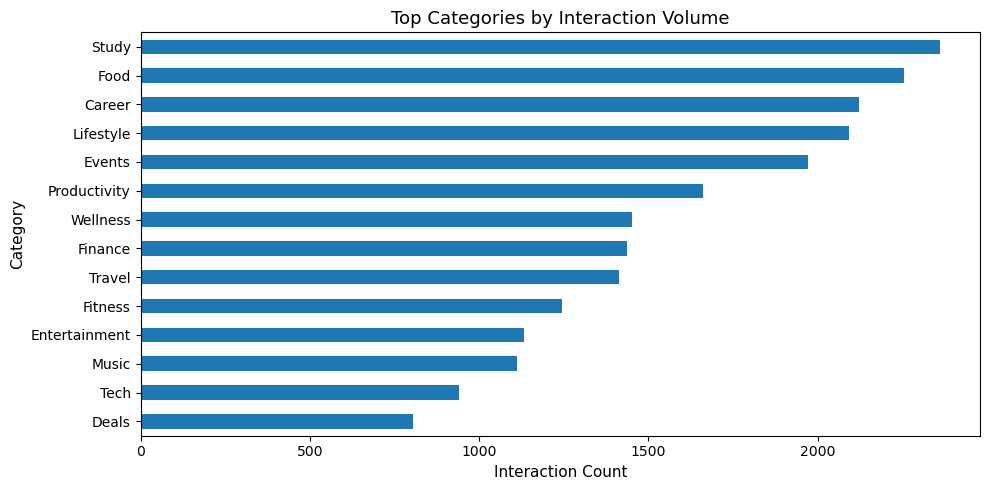

In [43]:
category_interactions = merged["category"].value_counts().head(15).sort_values(ascending=True)
category_interactions.plot(kind="barh")
plt.title("Top Categories by Interaction Volume")
plt.xlabel("Interaction Count")
plt.ylabel("Category")
plt.tight_layout()
plt.savefig(FIG_DIR / "interaction_volume_by_category.png", dpi=200, bbox_inches="tight")
plt.show()


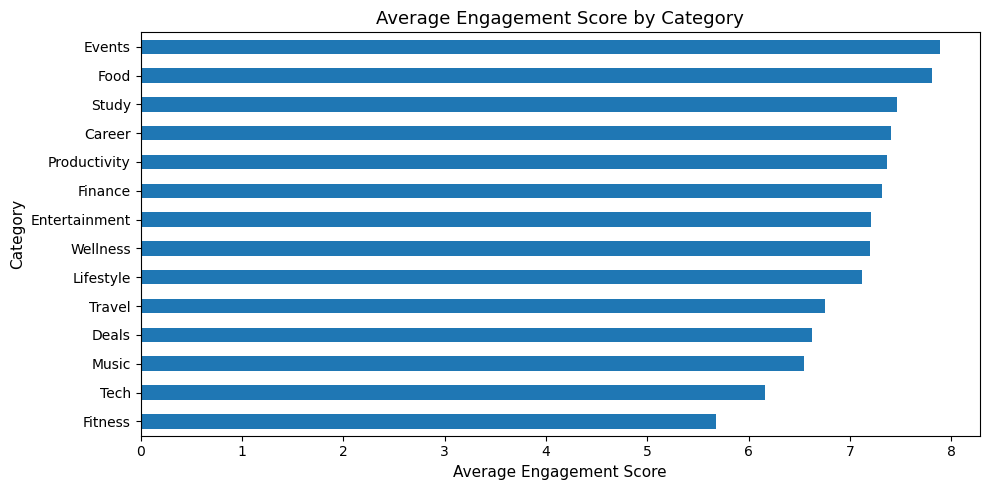

In [44]:
avg_engagement_by_category = (
    merged.groupby("category")["engagement_score"]
    .mean()
    .sort_values(ascending=True)
)

avg_engagement_by_category.plot(kind="barh")
plt.title("Average Engagement Score by Category")
plt.xlabel("Average Engagement Score")
plt.ylabel("Category")
plt.tight_layout()
plt.savefig(FIG_DIR / "avg_engagement_by_category.png", dpi=200, bbox_inches="tight")
plt.show()


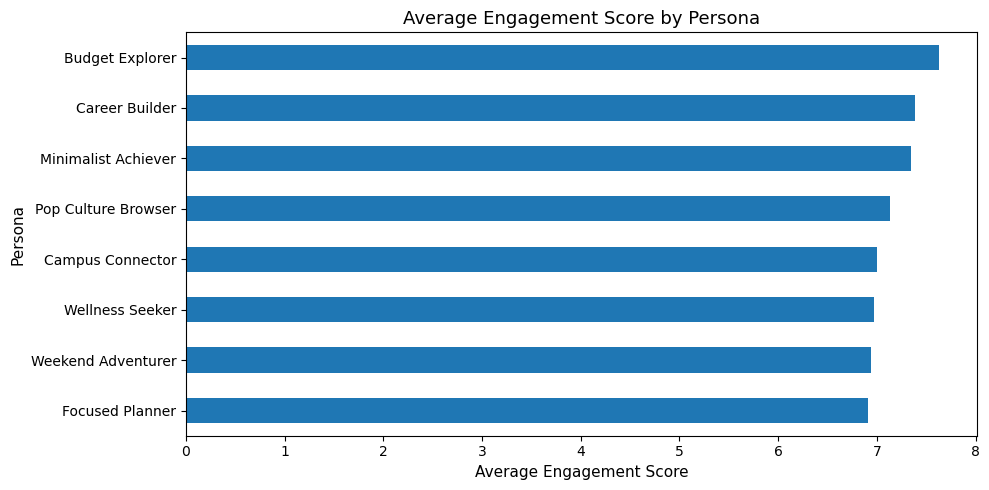

In [45]:
avg_engagement_by_persona = (
    merged.groupby("persona")["engagement_score"]
    .mean()
    .sort_values(ascending=True)
)

avg_engagement_by_persona.plot(kind="barh")
plt.title("Average Engagement Score by Persona")
plt.xlabel("Average Engagement Score")
plt.ylabel("Persona")
plt.tight_layout()
plt.savefig(FIG_DIR / "avg_engagement_by_persona.png", dpi=200, bbox_inches="tight")
plt.show()


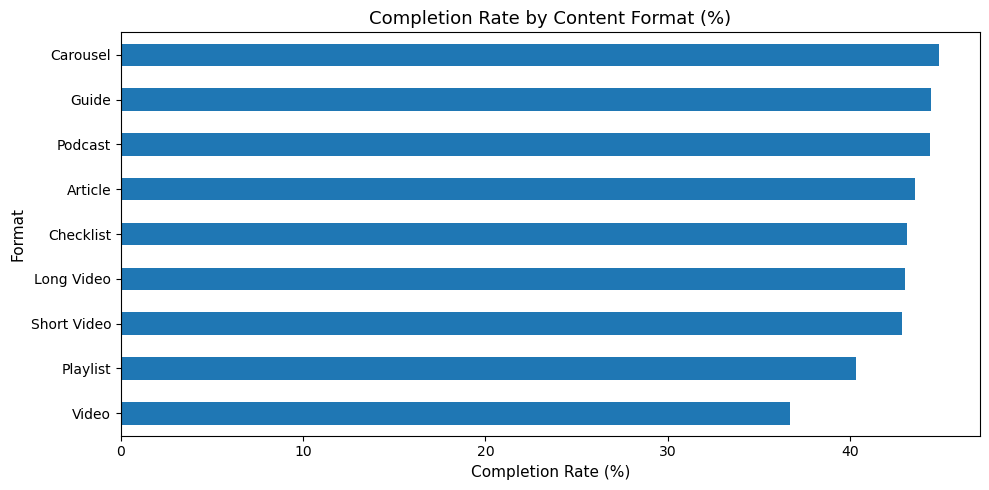

In [46]:
completion_by_format = (
    merged.groupby("format")["completed"]
    .mean()
    .sort_values(ascending=True) * 100
)

completion_by_format.plot(kind="barh")
plt.title("Completion Rate by Content Format (%)")
plt.xlabel("Completion Rate (%)")
plt.ylabel("Format")
plt.tight_layout()
plt.savefig(FIG_DIR / "completion_rate_by_format.png", dpi=200, bbox_inches="tight")
plt.show()


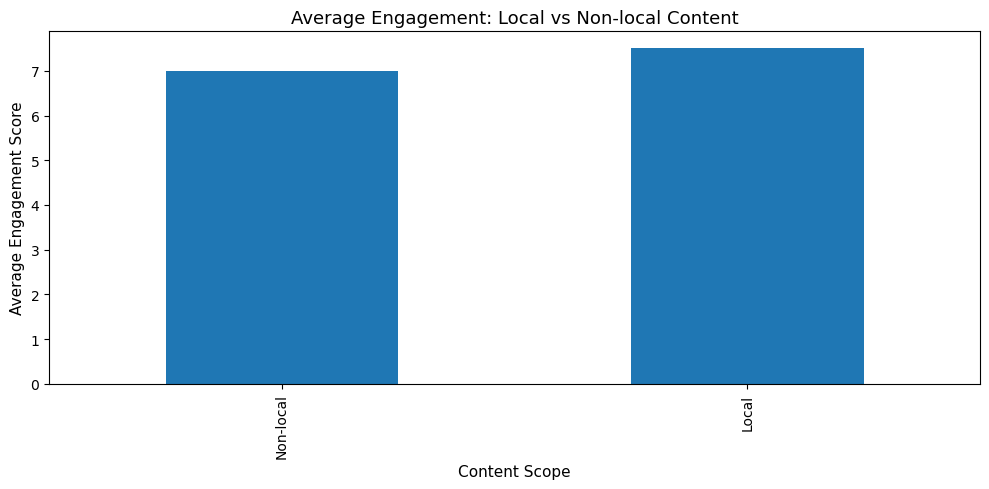

In [47]:
local_vs_nonlocal = (
    merged.groupby("is_local_content")["engagement_score"]
    .mean()
    .rename({0: "Non-local", 1: "Local"})
)

local_vs_nonlocal.plot(kind="bar")
plt.title("Average Engagement: Local vs Non-local Content")
plt.xlabel("Content Scope")
plt.ylabel("Average Engagement Score")
plt.tight_layout()
plt.savefig(FIG_DIR / "local_vs_nonlocal_engagement.png", dpi=200, bbox_inches="tight")
plt.show()


In [48]:
top_content = (
    merged.groupby(["content_id", "title", "category"])
    .agg(
        interaction_count=("interaction_id", "count"),
        avg_engagement=("engagement_score", "mean"),
        likes=("liked", "sum"),
        saves=("saved", "sum"),
        completions=("completed", "sum")
    )
    .reset_index()
    .sort_values(["avg_engagement", "interaction_count"], ascending=[False, False])
)

display(top_content.head(10))


,content_id,title,category,interaction_count,avg_engagement,likes,saves,completions
768,C0769,Easy Weekend Escapes You Can Do on a Budget Without Overspending,Travel,16,10.472500,9,6,11
894,C0895,Student Snacks That Feel Better Than Instant Noodles for Shared Kitchens,Food,20,10.382000,16,10,13
718,C0719,Budget-Friendly Food Spots Worth Trying This Week This Week,Food,26,9.738462,14,14,18
862,C0863,Planning Systems That Work Across Study and Life for Better Consistency,Productivity,25,9.725600,17,11,16
18,C0019,Local Events That Feel Social Without Being Too Much You’ll Actually Want to Attend,Events,30,9.634000,20,11,18
664,C0665,Hidden Day Trips Near Campus Worth the Train Fare for Weekend Plans,Travel,17,9.624706,10,9,11
692,C0693,Low-Cost Weekend Plans for Students Without Big Spending,Events,23,9.591304,13,9,15
892,C0893,Low-Cost Finds That Make Daily Life Easier That Actually Feel Useful,Deals,16,9.591250,11,7,11
32,C0033,Things to Do This Week Beyond the Usual Routine This Month,Events,24,9.560000,15,15,12
119,C0120,How to Organize a Semester Without Overcomplicating It for Better Consistency,Productivity,20,9.518000,16,10,13


## 14. EDA observations

Write a few short observations here after running the notebook. Example prompts:
- Which personas are most common?
- Which categories dominate the catalog?
- Which content formats have stronger completion rates?
- Are there any strange missing values or repeated interaction patterns?
- Which categories or personas show stronger average engagement?


## 15. Save lightweight analysis outputs for later notebooks

In [49]:
# Save a few helper summaries for reuse later if needed
category_summary = (
    merged.groupby("category")
    .agg(
        interaction_count=("interaction_id", "count"),
        avg_engagement=("engagement_score", "mean"),
        like_rate=("liked", "mean"),
        save_rate=("saved", "mean"),
        completion_rate=("completed", "mean")
    )
    .reset_index()
)

persona_summary = (
    merged.groupby("persona")
    .agg(
        users=("user_id", "nunique"),
        interaction_count=("interaction_id", "count"),
        avg_engagement=("engagement_score", "mean")
    )
    .reset_index()
)

category_summary.to_csv(METRICS_DIR / "category_summary.csv", index=False)
persona_summary.to_csv(METRICS_DIR / "persona_summary.csv", index=False)

print("Saved summary CSV files to results/metrics/.")


Saved summary CSV files to results/metrics/.
